# Training Frequency, Weekly Volume and Muscle and Strength Gains

**DATA200 Applied Statistical Analysis, group project**
Navaraj Thapa, Abdul Sheikh, Shishir Sharma, Prasanna Shakya

This notebook analyzes real, published data from a resistance-training meta-analysis. We ask whether training more often per week, and doing more sets per week, go with bigger gains in muscle size and strength.

## 2. Research questions and hypotheses

We test each hypothesis at a two-sided α = .05. We wrote them before running any model.

| RQ | Question | Null hypothesis (H₀) |
|---|---|---|
| 1 | Is weekly training frequency related to muscle growth (hypertrophy), after accounting for volume? | Frequency has no association with hypertrophy. |
| 2 | Is weekly volume (sets per muscle per week) related to hypertrophy? | Volume has no association with hypertrophy. |
| 3 | Are frequency and volume related to strength gain? | Neither is associated with strength gain. |
| 4 | Does the effect of frequency depend on how many weekly sets are done? | There is no frequency × volume interaction. |

Both outcomes are measured as **percent change from the pre-training average**, so studies that used different tests can be compared. This is an association study of group averages. It cannot show what training does to one person.

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

RAW = Path("../data/raw/pelland_extracted_data.xlsx")
FIG, TAB, PROC = Path("../results/figures"), Path("../results/tables"), Path("../data/processed")
for p in (FIG, TAB, PROC):
    p.mkdir(parents=True, exist_ok=True)

BLUE, NAVY, GREY = "#1E63D6", "#0A2540", "#8A96A8"
COL = {"Hypertrophy": BLUE, "Strength": NAVY}
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110})

RES = {}   # numbers we reuse later in the report and slides

## 3. Loading the raw file

In [2]:
raw = pd.read_excel(RAW)
print("rows x columns:", raw.shape)
print("studies:", raw["number"].nunique(), "| groups:", raw[["number", "group"]].drop_duplicates().shape[0])
print("duplicate rows:", int(raw.duplicated().sum()))
print(raw["outcome"].value_counts().to_string())
RES["raw"] = {"rows": int(raw.shape[0]), "cols": int(raw.shape[1]), "studies": int(raw["number"].nunique()),
              "groups": int(raw[["number", "group"]].drop_duplicates().shape[0]),
              "dup_rows": int(raw.duplicated().sum()), "hyp_rows": int((raw.outcome == "Hypertrophy").sum()),
              "str_rows": int((raw.outcome == "Strength").sum())}

rows x columns: (710, 95)
studies: 70 | groups: 168
duplicate rows: 0
outcome
Strength       490
Hypertrophy    220


We only need a handful of the 95 columns. This is what each one means.

| Column | Meaning | Our name |
|---|---|---|
| `number`, `group` | study id and group within the study | `study`, `group` |
| `outcome` | Hypertrophy or Strength | `outcome` |
| `pre.mean`, `post.mean` | group average before and after training | used to make the outcome |
| `frequency.all` | training sessions per muscle per week | `freq` |
| `sets.week.all` | hard sets per muscle per week | `sets` |
| `weeks` | length of the training period | `weeks` |
| `age`, `sex.male`, `train.status` | group age, percent male, trained or untrained | `age`, `male`, `status` |
| `n` | people in the group | `n` |

## 4. Cleaning

### 4.1 Missing values and impossible values
We check the columns we plan to use before doing anything else.

In [3]:
use = ["pre.mean", "post.mean", "frequency.all", "sets.week.all", "weeks", "age", "sex.male", "train.status", "n", "design"]
miss = raw[use].isna().sum().rename("missing").to_frame()
miss["percent"] = (miss["missing"] / len(raw) * 100).round(1)
display(miss)
print("pre.mean <= 0:", int((raw["pre.mean"] <= 0).sum()), "| post.mean <= 0:", int((raw["post.mean"] <= 0).sum()))
print("frequency 0 rows:", int((raw["frequency.all"] == 0).sum()), "| sets 0 rows:", int((raw["sets.week.all"] == 0).sum()))
RES["missing"] = {k: int(v) for k, v in miss["missing"].items()}

,missing,percent
pre.mean,0,0.0
post.mean,0,0.0
frequency.all,0,0.0
sets.week.all,0,0.0
weeks,0,0.0
age,0,0.0
sex.male,8,1.1
train.status,0,0.0
n,0,0.0
design,0,0.0


pre.mean <= 0: 0 | post.mean <= 0: 0
frequency 0 rows: 60 | sets 0 rows: 60


Only `sex.male` has missing values (8 rows). Nothing is impossible: every average is positive.

Some rows have frequency 0 and 0 sets. Those are **no-training control groups**. They do not describe a training dose, so we keep them out of the dose-response models. We use them once, in section 4.3, as a sanity check.

### 4.2 Building the outcome

For each row we compute the percent change from the group's own starting average: (post − pre) / pre × 100. A study that measured thigh thickness in millimetres and one that measured a squat 1RM in kilograms then sit on the same scale.

In [4]:
d = raw.copy()
d["pct_change"] = (d["post.mean"] - d["pre.mean"]) / d["pre.mean"] * 100
d["log_ratio"] = 100 * np.log(d["post.mean"] / d["pre.mean"])     # used later as a robustness check
d["trains"] = (d["frequency.all"] > 0) & (d["sets.week.all"] > 0)
print(d["pct_change"].describe().round(2).to_string())

count    710.00
mean      11.66
std       10.99
min      -13.97
25%        4.86
50%        9.72
75%       16.22
max       66.69


### 4.3 Control groups as a sanity check
If the outcome is built correctly, groups that did not train should barely change and trained groups should improve.

In [5]:
chk = d.groupby(["outcome", "trains"])["pct_change"].agg(["count", "mean", "median", "std"]).round(2)
chk.index = chk.index.set_levels(["control (no training)", "training"], level=1)
display(chk)
RES["controls"] = {f"{o}|{'train' if t else 'control'}": {"rows": int(r["count"]), "mean": round(float(r["mean"]), 2)}
                   for (o, t), r in d.groupby(["outcome", "trains"])["pct_change"].agg(["count", "mean"]).iterrows()}

count   mean  median    std
outcome     trains                                            
Hypertrophy control (no training)     11  -0.31   -0.18   1.43
            training                 209   6.99    6.13   5.04
Strength    control (no training)     49  -2.72   -2.16   4.49
            training                 441  15.77   12.72  11.24

### 4.4 One row per group and outcome
A group often has several measures of the same outcome (for example bench press and squat). Treating them as separate rows would count the same people several times. We average the percent change over the measures within each group and outcome. That gives one row per group and outcome.

In [6]:
g = (d[d["trains"]]
     .groupby(["number", "group", "outcome"])
     .agg(first_author=("first.author", "first"), year=("year", "first"),
          pct_change=("pct_change", "mean"), log_ratio=("log_ratio", "mean"),
          freq=("frequency.all", "mean"), sets=("sets.week.all", "mean"), weeks=("weeks", "first"),
          age=("age", "first"), male=("sex.male", "first"), status=("train.status", "first"),
          n=("n", "mean"), design=("design", "first"), measures=("pct_change", "size"))
     .reset_index().rename(columns={"number": "study"}))
print("groups x outcomes before dropping missing sex:", g.shape[0])
print(g.groupby("outcome").agg(groups=("group", "size"), studies=("study", "nunique")).to_string())
print("missing sex.male:", int(g["male"].isna().sum()))
g = g.dropna(subset=["male"]).copy()
g["trained"] = (g["status"] == "trained").astype(int)
g["freq_cat"] = pd.cut(g["freq"], [0, 1.25, 2.25, 10], labels=["1 or fewer", "2", "3 or more"])
g.to_csv(PROC / "analysis_groups.csv", index=False)
print("analysis rows:", g.shape[0])
print(g.groupby("outcome").agg(groups=("group", "size"), studies=("study", "nunique")).to_string())
RES["analysis"] = {o: {"groups": int(x.shape[0]), "studies": int(x["study"].nunique())} for o, x in g.groupby("outcome")}
RES["analysis"]["dropped_missing_sex"] = 4

groups x outcomes before dropping missing sex: 233
             groups  studies
outcome                     
Hypertrophy      81       37
Strength        152       69
missing sex.male: 4
analysis rows: 229
             groups  studies
outcome                     
Hypertrophy      79       36
Strength        150       68


We dropped 4 groups with no sex information (2 hypertrophy and 2 strength groups). The cleaned table is saved to `data/processed/analysis_groups.csv`.

### 4.5 Outliers
We flag unusual percent changes with the 1.5 × IQR rule. We keep them, because large gains happen in untrained beginners, but we test how much they matter in section 9.

In [7]:
def iqr_flags(s):
    q1, q3 = s.quantile([.25, .75]); k = q3 - q1
    return (s < q1 - 1.5 * k) | (s > q3 + 1.5 * k)
g["outlier"] = g.groupby("outcome")["pct_change"].transform(iqr_flags)
print(g.groupby("outcome")["outlier"].agg(["sum", "size"]).to_string())
print(g.loc[g.outlier, ["first_author", "year", "outcome", "pct_change", "status", "weeks"]].round(1).to_string(index=False))
RES["outliers"] = {o: int(x.outlier.sum()) for o, x in g.groupby("outcome")}

             sum  size
outcome               
Hypertrophy    3    79
Strength       2   150
first_author  year     outcome  pct_change    status  weeks
  Hamarsland  2022 Hypertrophy        19.2   trained    9.0
  Hamarsland  2022 Hypertrophy        20.8   trained    9.0
    Radaelli  2015 Hypertrophy        19.2 untrained   24.3
        Ochi  2018    Strength        48.3 untrained   10.0
        Ochi  2018    Strength        55.5 untrained   10.0


## 5. Exploratory data analysis

### 5.1 Who is in the data

In [8]:
def desc(x):
    return pd.Series({
        "groups": len(x), "studies": x["study"].nunique(), "people per group (mean)": x["n"].mean(),
        "% change, mean": x["pct_change"].mean(), "% change, SD": x["pct_change"].std(),
        "sessions/week, mean": x["freq"].mean(), "sets/week, mean": x["sets"].mean(),
        "weeks, mean": x["weeks"].mean(), "age, mean": x["age"].mean(), "% male, mean": x["male"].mean(),
        "% trained groups": x["trained"].mean() * 100})
table1 = g.groupby("outcome").apply(desc).T.round(2)
display(table1)
table1.to_csv(TAB / "table1_descriptives.csv")
RES["desc"] = {o: {k: round(float(v), 2) for k, v in table1[o].items()} for o in table1.columns}

outcome,Hypertrophy,Strength
groups,79.00,150.00
studies,36.00,68.00
people per group (mean),12.55,12.44
"% change, mean",7.17,16.06
"% change, SD",4.64,10.19
"sessions/week, mean",2.34,2.33
"sets/week, mean",14.66,12.98
"weeks, mean",9.71,9.59
"age, mean",23.88,24.39
"% male, mean",91.32,83.55


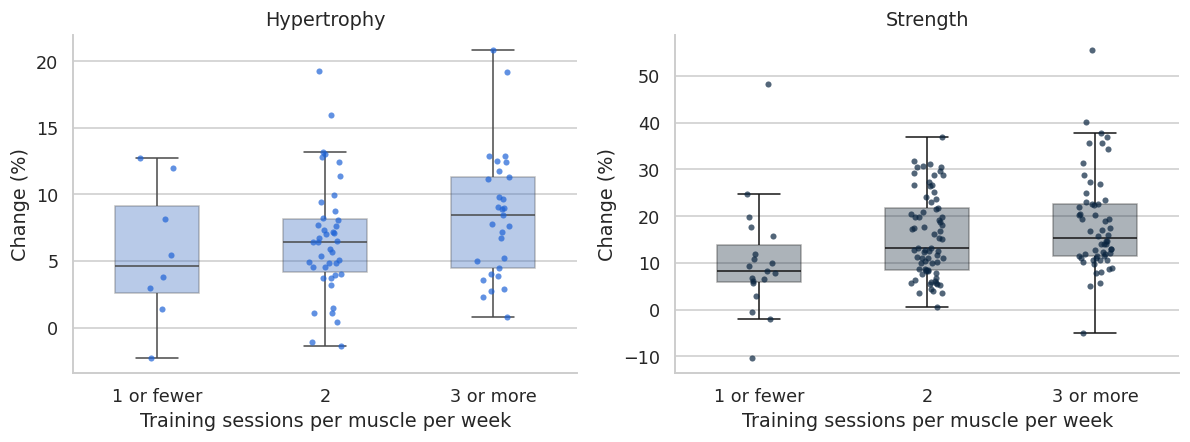

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for a, o in zip(ax, ["Hypertrophy", "Strength"]):
    x = g[g.outcome == o]
    sns.boxplot(data=x, x="freq_cat", y="pct_change", color=COL[o], width=.5, fliersize=0, ax=a, boxprops={"alpha": .35})
    sns.stripplot(data=x, x="freq_cat", y="pct_change", color=COL[o], size=4, alpha=.7, ax=a)
    a.set_title(f"{o}"); a.set_xlabel("Training sessions per muscle per week"); a.set_ylabel("Change (%)")
plt.tight_layout(); plt.savefig(FIG / "fig1_boxplots_frequency.png", dpi=200); plt.show()

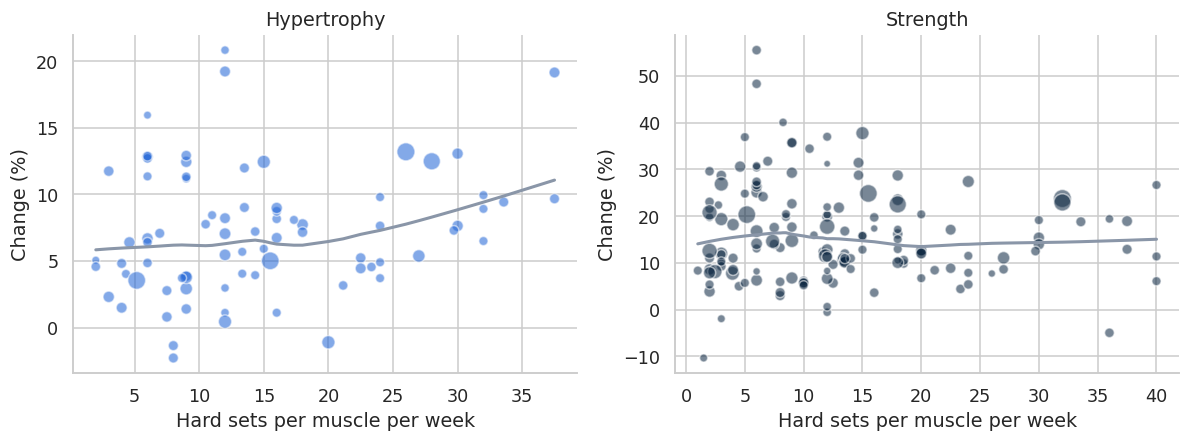

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for a, o in zip(ax, ["Hypertrophy", "Strength"]):
    x = g[g.outcome == o]
    a.scatter(x["sets"], x["pct_change"], s=x["n"] * 4, color=COL[o], alpha=.55, edgecolor="white")
    sns.regplot(data=x, x="sets", y="pct_change", scatter=False, lowess=True, color=GREY, ax=a, line_kws={"lw": 2})
    a.set_title(o); a.set_xlabel("Hard sets per muscle per week"); a.set_ylabel("Change (%)")
plt.tight_layout(); plt.savefig(FIG / "fig2_scatter_volume.png", dpi=200); plt.show()

### 5.2 Correlations
Pearson correlation between each predictor and the outcome, with Holm's adjustment for running several tests at once. We add Spearman's rank correlation, which does not need a straight-line pattern.

In [11]:
rows = []
for o in ["Hypertrophy", "Strength"]:
    x = g[g.outcome == o]
    for v, lab in [("freq", "Frequency"), ("sets", "Weekly sets"), ("weeks", "Weeks"), ("age", "Age"), ("male", "% male"), ("trained", "Trained")]:
        r, p = stats.pearsonr(x[v], x["pct_change"]); rs, ps = stats.spearmanr(x[v], x["pct_change"])
        rows.append({"outcome": o, "predictor": lab, "r": r, "p": p, "spearman": rs, "p_spearman": ps})
cor = pd.DataFrame(rows)
cor["p_holm"] = np.nan
for o in cor.outcome.unique():
    m = cor.outcome == o
    cor.loc[m, "p_holm"] = multipletests(cor.loc[m, "p"], method="holm")[1]
cor = cor.round(3); display(cor)
cor.to_csv(TAB / "table2_correlations.csv", index=False)
RES["cor"] = cor.to_dict(orient="records")

,outcome,predictor,r,p,spearman,p_spearman,p_holm
0,Hypertrophy,Frequency,0.274,0.014,0.266,0.018,0.086
1,Hypertrophy,Weekly sets,0.205,0.070,0.215,0.057,0.281
2,Hypertrophy,Weeks,0.086,0.452,0.073,0.525,0.904
3,Hypertrophy,Age,-0.075,0.509,-0.098,0.389,0.904
4,Hypertrophy,% male,-0.197,0.082,-0.127,0.266,0.281
5,Hypertrophy,Trained,-0.228,0.043,-0.217,0.054,0.214
6,Strength,Frequency,0.212,0.009,0.282,0.000,0.046
7,Strength,Weekly sets,-0.093,0.259,-0.040,0.624,0.778
8,Strength,Weeks,0.070,0.393,0.170,0.037,0.786
9,Strength,Age,0.002,0.981,-0.002,0.981,0.981


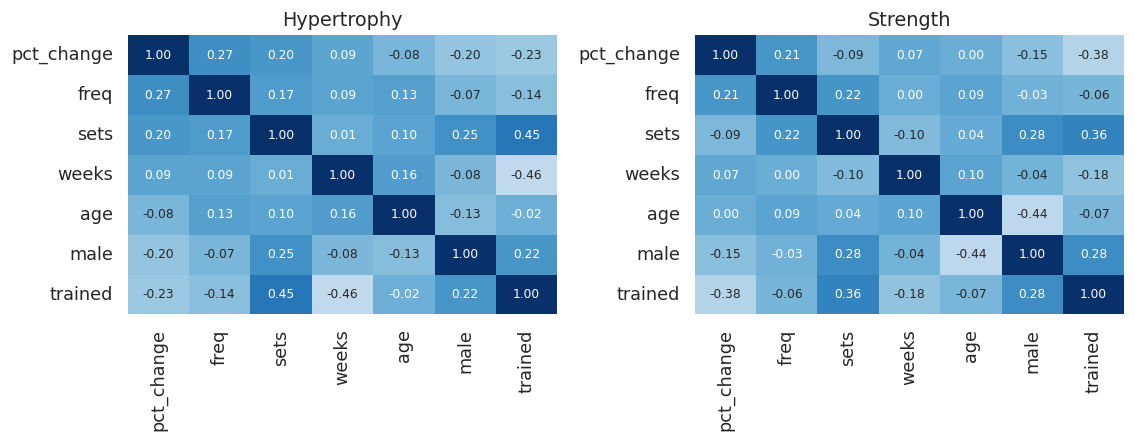

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.2))
for a, o in zip(ax, ["Hypertrophy", "Strength"]):
    x = g[g.outcome == o][["pct_change", "freq", "sets", "weeks", "age", "male", "trained"]]
    sns.heatmap(x.corr(), annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1, cbar=False, ax=a, annot_kws={"size": 8})
    a.set_title(o)
plt.tight_layout(); plt.savefig(FIG / "fig3_correlation_heatmap.png", dpi=200); plt.show()

**What we see.** Frequency is the predictor most tied to both outcomes (r = .27 for hypertrophy and r = .21 for strength). Weekly sets goes with hypertrophy (r = .21) but not with strength (r = −.09). Trained groups gain less than untrained ones (r = −.23 and −.38), which is what we expect, because beginners improve fastest. After Holm's adjustment only two correlations stay under .05: frequency with strength (p = .046) and training status with strength (p < .001). The scatter plot shows hypertrophy rising above about 20 sets a week, while strength looks flat across volume.

## 6. ANOVA and ANCOVA

We group frequency into three levels (1 or fewer, 2, and 3 or more sessions per muscle per week) and compare mean gains. One caution first: several groups come from the same study, and groups in one study are not independent. Classic ANOVA assumes independence, so we treat its p-values as descriptive. The regression in section 7 corrects for this with study-clustered standard errors, and we also run a cluster-robust test of the frequency groups below.

In [13]:
print(g.groupby(["outcome", "freq_cat"]).size().unstack().to_string())
aov = {}
for o in ["Hypertrophy", "Strength"]:
    x = g[g.outcome == o]
    m = smf.ols("pct_change ~ C(freq_cat)", x).fit()
    t = anova_lm(m, typ=2)
    ss_b, ss_t = t.loc["C(freq_cat)", "sum_sq"], t["sum_sq"].sum()
    aov[o] = {"F": t.loc["C(freq_cat)", "F"], "df1": int(t.loc["C(freq_cat)", "df"]), "df2": int(t.loc["Residual", "df"]),
              "p": t.loc["C(freq_cat)", "PR(>F)"], "eta2": ss_b / ss_t}
    lv = [x.loc[x.freq_cat == c, "pct_change"] for c in x.freq_cat.cat.categories]
    aov[o]["levene_p"] = stats.levene(*lv).pvalue
    aov[o]["means"] = x.groupby("freq_cat")["pct_change"].mean().round(2).to_dict()
    print(o, {k: (round(v, 3) if isinstance(v, float) else v) for k, v in aov[o].items() if k != "means"}, aov[o]["means"])
    print(pairwise_tukeyhsd(x["pct_change"], x["freq_cat"]).summary())
RES["anova"] = {o: {k: (round(float(v), 4) if not isinstance(v, dict) and not isinstance(v, int) else v) for k, v in a.items()} for o, a in aov.items()}

freq_cat     1 or fewer   2  3 or more
outcome                               
Hypertrophy           8  42         29
Strength             19  73         58
Hypertrophy {'F': np.float64(1.881), 'df1': 2, 'df2': 76, 'p': np.float64(0.159), 'eta2': np.float64(0.047), 'levene_p': np.float64(0.642)} {'1 or fewer': 5.52, '2': 6.63, '3 or more': 8.42}
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1     group2  meandiff p-adj   lower  upper  reject
----------------------------------------------------------
1 or fewer         2   1.1068 0.8064 -3.1208 5.3344  False
1 or fewer 3 or more   2.8942 0.2601 -1.4824 7.2707  False
         2 3 or more   1.7873 0.2457 -0.8586 4.4333  False
----------------------------------------------------------
Strength {'F': np.float64(4.373), 'df1': 2, 'df2': 147, 'p': np.float64(0.014), 'eta2': np.float64(0.056), 'levene_p': np.float64(0.979)} {'1 or fewer': 10.55, '2': 15.75, '3 or more': 18.27}


    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1     group2  meandiff p-adj   lower   upper  reject
-----------------------------------------------------------
1 or fewer         2   5.1999 0.1095 -0.8762 11.2761  False
1 or fewer 3 or more   7.7252 0.0108  1.4889 13.9615   True
         2 3 or more   2.5252 0.3228 -1.6246  6.6751  False
-----------------------------------------------------------


**One-way ANOVA.** For hypertrophy the group means rise from 5.5% (1 or fewer sessions) to 6.6% (2) to 8.4% (3 or more), but the differences are not significant, F(2, 76) = 1.88, p = .159, η² = .047. For strength the means rise from 10.6% to 15.8% to 18.3%, F(2, 147) = 4.37, p = .014, η² = .056. Tukey's test says only one pair differs: 3 or more sessions beat 1 or fewer by 7.7 points (95% CI 1.5 to 14.0, p = .011). Levene's test shows no problem with equal spread (p = .642 and .979). Only 8 hypertrophy groups and 19 strength groups sit in the lowest frequency category, so those comparisons are shaky.

Next is the ANCOVA: the same three frequency groups, but adjusted for weekly sets, weeks, age, percent male and training status. We test the frequency groups with study-clustered standard errors.

In [14]:
anc = {}
for o in ["Hypertrophy", "Strength"]:
    x = g[g.outcome == o].copy()
    x["sets10"] = (x["sets"] - x["sets"].mean()) / 10
    x["weeks_c"] = x["weeks"] - x["weeks"].mean(); x["age_c"] = x["age"] - x["age"].mean(); x["male_c"] = x["male"] / 100 - (x["male"] / 100).mean()
    x["fc"] = x["freq_cat"].map({"1 or fewer": "f1", "2": "f2", "3 or more": "f3"})
    f = "pct_change ~ C(fc) + sets10 + weeks_c + age_c + male_c + trained"
    m = smf.ols(f, x).fit()
    t = anova_lm(m, typ=2)
    pe = t.loc["C(fc)", "sum_sq"] / (t.loc["C(fc)", "sum_sq"] + t.loc["Residual", "sum_sq"])
    mc = smf.ols(f, x).fit(cov_type="cluster", cov_kwds={"groups": x["study"]}, use_t=True)
    w = mc.wald_test("C(fc)[T.f2] = 0, C(fc)[T.f3] = 0", use_f=True, scalar=True)
    # adjusted means: everyone at the average covariate values
    base = {c: 0 for c in ["sets10", "weeks_c", "age_c", "male_c"]}; base["trained"] = x["trained"].mean()
    new = pd.DataFrame([{**base, "fc": c} for c in ["f1", "f2", "f3"]])
    am = m.get_prediction(new).summary_frame()[["mean", "mean_ci_lower", "mean_ci_upper"]]
    am.index = ["1 or fewer", "2", "3 or more"]
    anc[o] = {"F": float(t.loc["C(fc)", "F"]), "df1": int(t.loc["C(fc)", "df"]), "df2": int(t.loc["Residual", "df"]),
              "p": float(t.loc["C(fc)", "PR(>F)"]), "partial_eta2": float(pe),
              "F_cluster": float(w.statistic), "p_cluster": float(w.pvalue), "adj_means": am.round(2).to_dict(orient="index")}
    print(o, {k: round(v, 3) for k, v in anc[o].items() if k != "adj_means"})
    display(am.round(2))
RES["ancova"] = anc

Hypertrophy {'F': 0.426, 'df1': 2, 'df2': 71, 'p': 0.655, 'partial_eta2': 0.012, 'F_cluster': 0.602, 'p_cluster': 0.553}


,mean,mean_ci_lower,mean_ci_upper
1 or fewer,6.80,3.76,9.84
2,6.82,5.51,8.13
3 or more,7.78,6.16,9.40


Strength {'F': 2.864, 'df1': 2, 'df2': 142, 'p': 0.06, 'partial_eta2': 0.039, 'F_cluster': 2.727, 'p_cluster': 0.073}


,mean,mean_ci_lower,mean_ci_upper
1 or fewer,12.10,7.59,16.60
2,15.46,13.26,17.67
3 or more,18.12,15.62,20.62


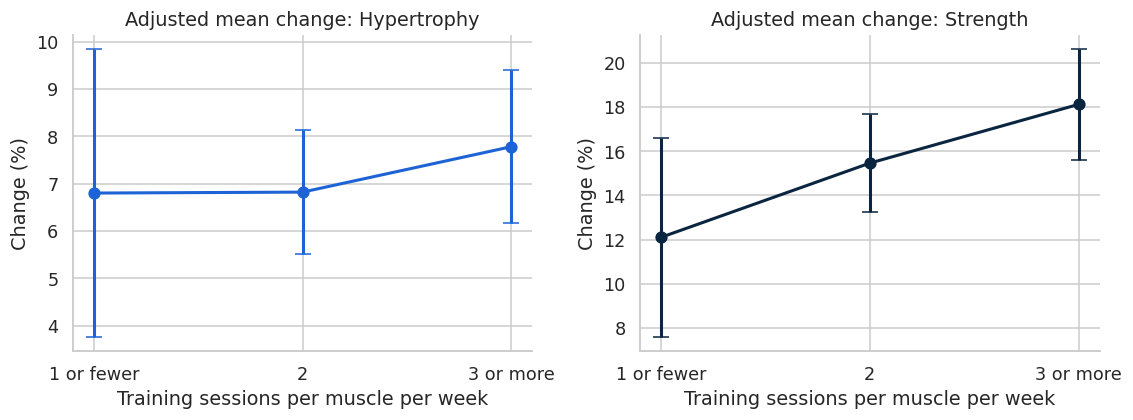

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4))
for a, o in zip(ax, ["Hypertrophy", "Strength"]):
    am = pd.DataFrame(anc[o]["adj_means"]).T
    a.errorbar(range(3), am["mean"], yerr=[am["mean"] - am["mean_ci_lower"], am["mean_ci_upper"] - am["mean"]],
               fmt="o-", color=COL[o], capsize=5, lw=2, ms=7)
    a.set_xticks(range(3)); a.set_xticklabels(am.index); a.set_title(f"Adjusted mean change: {o}")
    a.set_xlabel("Training sessions per muscle per week"); a.set_ylabel("Change (%)")
plt.tight_layout(); plt.savefig(FIG / "fig4_adjusted_means.png", dpi=200); plt.show()

**ANCOVA.** Once we adjust for weekly sets, weeks, age, sex and training status, the hypertrophy differences disappear: F(2, 71) = 0.43, p = .655, partial η² = .012, with adjusted means of 6.8%, 6.8% and 7.8%. For strength the pattern stays in the same direction but weakens: adjusted means 12.1%, 15.5% and 18.1%, F(2, 142) = 2.86, p = .060 (study-clustered test p = .073), partial η² = .039. So the ANOVA result for strength is partly explained by the other variables, and the regression below gives a cleaner answer.

## 7. Regression models

Each outcome gets its own set of models. Three choices to explain:

1. **Weights.** A group with 30 people gives a more precise average than a group with 6. We weight each group by its number of people (weighted least squares).
2. **Clustered standard errors.** Groups in the same study share the same lab, test and population. We cluster standard errors by study so the p-values are not too optimistic. We also fit a mixed model with a random intercept for study as a check in section 9.
3. **Centered predictors.** Frequency, weekly sets (in units of 10 sets), weeks, age and percent male are centered, so the intercept is the typical group and coefficients read as "one step above typical".

The four models build up step by step:

| Model | Terms | Purpose |
|---|---|---|
| M1 | frequency + covariates | frequency alone |
| M2 | M1 + weekly sets | frequency after accounting for volume |
| M3 | M2 + frequency × weekly sets | does the frequency effect depend on volume? (RQ4) |
| M4 | M2 + weekly sets squared | diminishing returns for volume |

Covariates are weeks, age, percent male and training status.

In [16]:
def prep(o):
    x = g[g.outcome == o].copy().reset_index(drop=True)
    x["f_c"] = x["freq"] - x["freq"].mean()
    x["s_c"] = (x["sets"] - x["sets"].mean()) / 10          # per 10 weekly sets
    x["w_c"] = x["weeks"] - x["weeks"].mean()
    x["age_c"] = x["age"] - x["age"].mean()
    x["male_c"] = x["male"] / 100 - (x["male"] / 100).mean()
    return x

D = {o: prep(o) for o in ["Hypertrophy", "Strength"]}
COV = "w_c + age_c + male_c + trained"
FORM = {"M1": f"pct_change ~ f_c + {COV}",
        "M2": f"pct_change ~ f_c + s_c + {COV}",
        "M3": f"pct_change ~ f_c + s_c + f_c:s_c + {COV}",
        "M4": f"pct_change ~ f_c + s_c + I(s_c**2) + {COV}"}

def fit(f, x, robust=True):
    m = smf.wls(f, x, weights=x["n"])
    return m.fit(cov_type="cluster", cov_kwds={"groups": x["study"]}, use_t=True) if robust else m.fit()

M = {o: {k: fit(f, D[o]) for k, f in FORM.items()} for o in D}
for o in D:
    print(f"\n===== {o}: {len(D[o])} groups, {D[o].study.nunique()} studies =====")
    for k, m in M[o].items():
        print(f"{k}: R2 = {m.rsquared:.3f}   adj R2 = {m.rsquared_adj:.3f}")


===== Hypertrophy: 79 groups, 36 studies =====
M1: R2 = 0.124   adj R2 = 0.064
M2: R2 = 0.283   adj R2 = 0.224
M3: R2 = 0.283   adj R2 = 0.213
M4: R2 = 0.290   adj R2 = 0.220

===== Strength: 150 groups, 68 studies =====
M1: R2 = 0.200   adj R2 = 0.172
M2: R2 = 0.205   adj R2 = 0.171
M3: R2 = 0.220   adj R2 = 0.182
M4: R2 = 0.216   adj R2 = 0.177


In [17]:
def coef_table(m):
    ci = m.conf_int()
    return pd.DataFrame({"b": m.params, "SE": m.bse, "t": m.tvalues, "p": m.pvalues, "CI low": ci[0], "CI high": ci[1]})

for o in D:
    print(f"\n--- {o}: Model 2 (main effects) ---"); display(coef_table(M[o]["M2"]).round(3))
    print(f"--- {o}: Model 3 (adds interaction) ---"); display(coef_table(M[o]["M3"]).round(3))


--- Hypertrophy: Model 2 (main effects) ---


,b,SE,t,p,CI low,CI high
Intercept,9.014,0.969,9.303,0.000,7.047,10.981
f_c,0.690,0.413,1.669,0.104,-0.149,1.529
s_c,2.395,0.633,3.784,0.001,1.110,3.680
w_c,-0.173,0.090,-1.931,0.062,-0.355,0.009
age_c,-0.269,0.199,-1.352,0.185,-0.673,0.135
male_c,-2.615,5.214,-0.502,0.619,-13.201,7.970
trained,-3.836,1.697,-2.260,0.030,-7.282,-0.390


--- Hypertrophy: Model 3 (adds interaction) ---


,b,SE,t,p,CI low,CI high
Intercept,9.011,1.027,8.773,0.000,6.926,11.096
f_c,0.689,0.436,1.581,0.123,-0.196,1.573
s_c,2.393,0.638,3.751,0.001,1.098,3.689
f_c:s_c,0.010,0.568,0.018,0.986,-1.144,1.164
w_c,-0.173,0.091,-1.893,0.067,-0.358,0.012
age_c,-0.269,0.201,-1.341,0.189,-0.676,0.138
male_c,-2.620,5.264,-0.498,0.622,-13.306,8.065
trained,-3.834,1.733,-2.213,0.034,-7.352,-0.316



--- Strength: Model 2 (main effects) ---


,b,SE,t,p,CI low,CI high
Intercept,20.024,1.673,11.967,0.000,16.684,23.364
f_c,1.975,0.862,2.291,0.025,0.254,3.697
s_c,0.811,0.961,0.844,0.402,-1.107,2.729
w_c,-0.021,0.197,-0.109,0.914,-0.414,0.371
age_c,-0.203,0.188,-1.079,0.285,-0.578,0.172
male_c,-3.020,4.419,-0.683,0.497,-11.841,5.800
trained,-7.547,2.145,-3.519,0.001,-11.827,-3.266


--- Strength: Model 3 (adds interaction) ---


,b,SE,t,p,CI low,CI high
Intercept,20.465,1.731,11.825,0.000,17.011,23.919
f_c,2.224,0.876,2.538,0.013,0.475,3.974
s_c,1.061,0.919,1.156,0.252,-0.772,2.895
f_c:s_c,-1.596,0.761,-2.097,0.040,-3.114,-0.077
w_c,-0.043,0.191,-0.228,0.821,-0.424,0.337
age_c,-0.222,0.189,-1.177,0.243,-0.598,0.154
male_c,-2.722,4.395,-0.619,0.538,-11.494,6.050
trained,-7.802,2.169,-3.596,0.001,-12.132,-3.472


In [18]:
reg = {}
for o in D:
    reg[o] = {}
    for k, m in M[o].items():
        t = coef_table(m)
        reg[o][k] = {"r2": float(m.rsquared), "adj_r2": float(m.rsquared_adj), "n": int(m.nobs),
                     "coef": {name: {c: float(v) for c, v in row.items()} for name, row in t.iterrows()}}
RES["reg"] = reg
rows = []
for o in D:
    for k in M[o]:
        for name, c in reg[o][k]["coef"].items():
            rows.append({"outcome": o, "model": k, "term": name, **{a: round(b, 4) for a, b in c.items()}})
pd.DataFrame(rows).to_csv(TAB / "table3_regression_all_models.csv", index=False)

### 7.1 
Coefficients are percentage points of change. "Per session" means one more training session per muscle per week. "Per 10 sets" means ten more hard sets per muscle per week.

**Hypertrophy (79 groups, 36 studies).**
- Frequency alone (M1) looks useful: +1.23 points per session (p = .006, R² = .12).
- Add weekly sets (M2) and frequency shrinks to +0.69 (95% CI −0.15 to 1.53, p = .104), while weekly sets takes over: +2.39 points per 10 sets (95% CI 1.11 to 3.68, p = .001). R² rises to .28. A lot of the frequency effect in M1 was really a volume effect, because groups that train more often also tend to do more sets.
- Trained groups gain 3.8 points less than untrained ones (p = .030).
- The interaction (M3) is essentially zero (0.01, p = .986), and the squared sets term (M4) is not significant (0.49, p = .437). We find no sign of diminishing returns inside the 2 to 38 sets we observe.
- **RQ1:** we do not reject H₀ (frequency, once volume is in the model). **RQ2:** we reject H₀. **RQ4 (hypertrophy):** we do not reject H₀.

**Strength (150 groups, 68 studies).**
- Frequency stays important after volume: +1.98 points per session (95% CI 0.25 to 3.70, p = .025). Weekly sets does not: +0.81 per 10 sets (95% CI −1.11 to 2.73, p = .402). R² = .205.
- Trained groups gain 7.5 points less than untrained groups (p = .001).
- The interaction is negative: −1.60 (95% CI −3.11 to −0.08, p = .040, R² = .22). The effect of one more session is about +3.7 points at low volume (about 3.5 sets a week), +2.2 at average volume (13 sets) and +0.7 at high volume (22 sets). More sessions help most when weekly volume is low.
- **RQ3:** we reject H₀ for frequency and do not reject it for volume. **RQ4 (strength):** p = .040 on its own, but the study-level bootstrap interval for the interaction (−3.36 to 0.02) just reaches zero, and we are testing four hypotheses. We call it suggestive, not settled.

## 8. Validation

### 8.1 Cross-validation that respects studies
If groups from the same study sit in both the training and test folds, the test looks easier than it is. We therefore split by **study**: whole studies go into either the training or the test fold. We repeat a 5-fold split 30 times with different random assignments.

In [19]:
def grouped_cv(f, x, reps=30, k=5, seed=11):
    rng = np.random.default_rng(seed); ids = x["study"].unique(); y = x["pct_change"].to_numpy()
    r2s, rmses = [], []
    for _ in range(reps):
        perm = rng.permutation(ids); fold = x["study"].map({s: i % k for i, s in enumerate(perm)}).to_numpy()
        pred = np.empty(len(x))
        for i in range(k):
            tr, te = x[fold != i], x[fold == i]
            pred[fold == i] = smf.wls(f, tr, weights=tr["n"]).fit().predict(te)
        r2s.append(1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()); rmses.append(np.sqrt(((y - pred) ** 2).mean()))
    return float(np.mean(r2s)), float(np.std(r2s)), float(np.mean(rmses))

# two reference points: the average alone (Null) and the covariates alone (M0, no frequency or volume)
FORM_CV = {"Null": "pct_change ~ 1", "M0": f"pct_change ~ {COV}", **FORM}
cv = {o: {k: dict(zip(["cv_r2", "cv_r2_sd", "cv_rmse"], grouped_cv(f, D[o]))) for k, f in FORM_CV.items()} for o in D}
cvt = pd.DataFrame({(o, k): v for o in cv for k, v in cv[o].items()}).T
cvt["train_r2"] = [reg[o][k]["r2"] if k in reg[o] else np.nan for o, k in cvt.index]
display(cvt.round(3))
cvt.round(4).to_csv(TAB / "table4_cross_validation.csv")
RES["cv"] = cv

cv_r2  cv_r2_sd  cv_rmse  train_r2
Hypertrophy Null -0.045     0.031    4.708       NaN
            M0   -0.431     0.197    5.499       NaN
            M1   -0.339     0.178    5.320     0.124
            M2   -0.150     0.136    4.931     0.283
            M3   -0.173     0.138    4.982     0.283
            M4   -0.186     0.143    5.009     0.290
Strength    Null -0.037     0.021   10.339       NaN
            M0    0.029     0.036   10.001       NaN
            M1    0.051     0.033    9.888     0.200
            M2    0.031     0.040    9.994     0.205
            M3    0.050     0.042    9.895     0.220
            M4    0.019     0.042   10.055     0.216

**Reading the table.** CV R² is the share of variation we predict for studies the model never saw. A value below zero means the model does worse than just guessing the overall average (the "Null" row).

- **Hypertrophy:** no model beats the overall average (Null CV R² = −.045). Among the models, adding weekly sets helps a lot: M2 scores −.150 (RMSE 4.93) versus −.339 for frequency alone (M1, RMSE 5.32) and −.431 for the covariates alone (M0). The groups come from only 36 studies and studies differ a lot from each other, so predicting a new study is hard.
- **Strength:** frequency adds a small amount. M1 (.051) and M3 (.050) do best, M2 gets .031, M4 .019, covariates alone .029, and the average alone −.037. The gains are small, about 5% of the variation.

**Model choice.** For hypertrophy we use **M2**, because it predicts new studies best among the models with frequency and volume, and the interaction and curve add nothing. For strength we report **M2** for the main effects and **M3** to answer RQ4, since M3 predicts new studies about as well as the simplest model.

### 8.2 Bootstrap by study
To see how stable the estimates are, we resample **whole studies** with replacement 2,000 times, refit the model each time, and take the 2.5th and 97.5th percentiles. Resampling single groups would ignore the clustering.

In [20]:
def cluster_boot(f, x, terms, B=2000, seed=21):
    rng = np.random.default_rng(seed); parts = {s: gp for s, gp in x.groupby("study")}; ids = np.array(list(parts))
    out = np.empty((B, len(terms)))
    for b in range(B):
        bs = pd.concat([parts[s] for s in rng.choice(ids, len(ids))])
        out[b] = smf.wls(f, bs, weights=bs["n"]).fit().params[terms].to_numpy()
    return out

boot = {}
for o in D:
    boot[o] = {}
    for k, terms in [("M2", ["f_c", "s_c"]), ("M3", ["f_c", "s_c", "f_c:s_c"])]:
        arr = cluster_boot(FORM[k], D[o], terms)
        boot[o][k] = {t: {"low": float(np.percentile(arr[:, i], 2.5)), "high": float(np.percentile(arr[:, i], 97.5)),
                          "est": float(M[o][k].params[t])} for i, t in enumerate(terms)}
        print(o, k, {t: (round(v["est"], 2), round(v["low"], 2), round(v["high"], 2)) for t, v in boot[o][k].items()})
RES["boot"] = boot

Hypertrophy M2 {'f_c': (0.69, -0.23, 1.48), 's_c': (2.39, 0.71, 3.66)}


Hypertrophy M3 {'f_c': (0.69, -0.32, 1.59), 's_c': (2.39, 0.69, 3.61), 'f_c:s_c': (0.01, -1.22, 1.37)}


Strength M2 {'f_c': (1.98, 0.43, 3.81), 's_c': (0.81, -1.36, 2.65)}


Strength M3 {'f_c': (2.22, 0.59, 4.03), 's_c': (1.06, -1.12, 2.76), 'f_c:s_c': (-1.6, -3.36, 0.02)}


**Bootstrap by study.** The study-level intervals agree with the clustered regression. Hypertrophy (M2): frequency 0.69 (95% CI −0.23 to 1.48), weekly sets 2.39 (0.71 to 3.66). Strength (M2): frequency 1.98 (0.43 to 3.81), weekly sets 0.81 (−1.36 to 2.65). The interaction: hypertrophy 0.01 (−1.22 to 1.37), strength −1.60 (−3.36 to 0.02).

### 8.3 Assumption checks

We check Model 2 for each outcome: normal residuals (Shapiro–Wilk), constant spread (Breusch–Pagan), correct form (RESET), collinearity (VIF), influential points (Cook's distance), and how much of the variation sits between studies (intraclass correlation from a mixed model with no predictors).

In [21]:
diag = {}
for o in D:
    x = D[o]; m = fit(FORM["M2"], x, robust=False)
    infl = OLSInfluence(m); cooks = infl.cooks_distance[0]
    X = m.model.exog; vif = {n: variance_inflation_factor(X, i) for i, n in enumerate(m.model.exog_names) if n != "Intercept"}
    null = smf.mixedlm("pct_change ~ 1", x, groups=x["study"]).fit()
    icc = float(null.cov_re.iloc[0, 0] / (null.cov_re.iloc[0, 0] + null.scale))
    diag[o] = {"shapiro_p": float(stats.shapiro(m.wresid).pvalue), "bp_p": float(het_breuschpagan(m.wresid, m.model.exog)[1]),
               "reset_p": float(linear_reset(m, power=2, use_f=True).pvalue), "max_vif": float(max(vif.values())),
               "max_cooks": float(np.max(cooks)), "icc": icc}
    print(o, {k: round(v, 3) for k, v in diag[o].items()})
RES["diag"] = diag

Hypertrophy {'shapiro_p': 0.006, 'bp_p': 0.052, 'reset_p': 0.873, 'max_vif': 1.836, 'max_cooks': 0.006, 'icc': 0.546}
Strength {'shapiro_p': 0.003, 'bp_p': 0.065, 'reset_p': 0.742, 'max_vif': 1.448, 'max_cooks': 0.002, 'icc': 0.811}


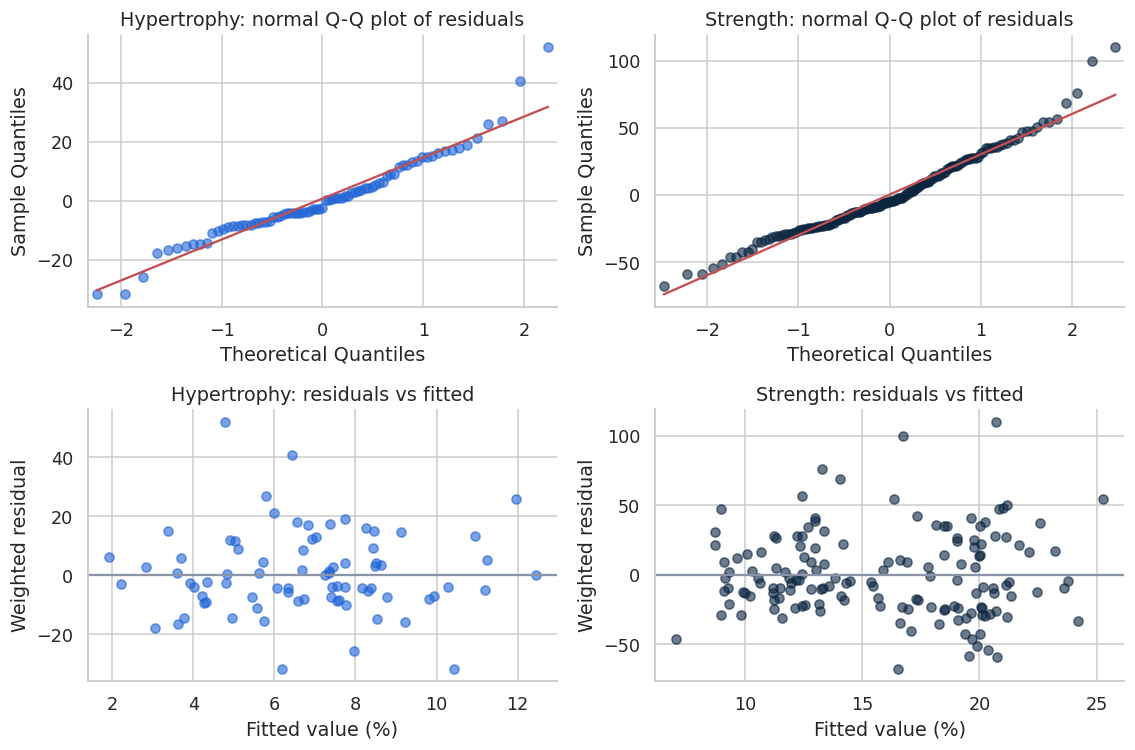

In [22]:
fig, ax = plt.subplots(2, 2, figsize=(10.5, 7))
for j, o in enumerate(D):
    m = fit(FORM["M2"], D[o], robust=False); r = m.wresid
    sm.qqplot(r, line="s", ax=ax[0, j], markerfacecolor=COL[o], markeredgecolor=COL[o], alpha=.6)
    ax[0, j].set_title(f"{o}: normal Q-Q plot of residuals")
    ax[1, j].scatter(m.fittedvalues, r, color=COL[o], alpha=.6); ax[1, j].axhline(0, color=GREY)
    ax[1, j].set_xlabel("Fitted value (%)"); ax[1, j].set_ylabel("Weighted residual"); ax[1, j].set_title(f"{o}: residuals vs fitted")
plt.tight_layout(); plt.savefig(FIG / "fig5_diagnostics.png", dpi=200); plt.show()

**What the checks show.**
- Residuals are not perfectly normal (Shapiro–Wilk p = .006 for hypertrophy and .003 for strength). The Q-Q plots show a few unusually large gains. That is why we lean on study-clustered standard errors and the study-level bootstrap and do not rely on normal-theory p-values.
- Spread is close to constant (Breusch–Pagan p = .052 and .065), borderline but not a clear problem.
- The model form is fine (RESET p = .873 and .742), and collinearity is low (largest VIF 1.84 and 1.45).
- No group has real influence (largest Cook's distance 0.006 and 0.002).
- Most of the variation sits **between studies**: the intraclass correlation is .55 for hypertrophy and .81 for strength. This confirms that treating groups as independent would have overstated how much information we have.

## 9. Robustness

We rerun the main-effects model (M2) five ways and compare the frequency and volume coefficients. If the story only held under one setup, we would not trust it.

1. **Main**: weighted least squares, study-clustered standard errors.
2. **Unweighted**: ordinary least squares, study-clustered standard errors.
3. **Mixed model**: random intercept for study.
4. **Log ratio outcome**: 100 × ln(post / pre) in place of percent change.
5. **No outliers**: the groups flagged in section 4.5 removed.

In [23]:
def variants(o):
    x = D[o]; out = {}
    out["Main (WLS, clustered)"] = fit(FORM["M2"], x)
    out["Unweighted (OLS, clustered)"] = smf.ols(FORM["M2"], x).fit(cov_type="cluster", cov_kwds={"groups": x["study"]}, use_t=True)
    out["Mixed model (study intercept)"] = smf.mixedlm(FORM["M2"], x, groups=x["study"]).fit()
    out["Log-ratio outcome"] = smf.wls(FORM["M2"].replace("pct_change", "log_ratio"), x, weights=x["n"]).fit(cov_type="cluster", cov_kwds={"groups": x["study"]}, use_t=True)
    xo = x[~x["outlier"]]
    out["No outliers"] = smf.wls(FORM["M2"], xo, weights=xo["n"]).fit(cov_type="cluster", cov_kwds={"groups": xo["study"]}, use_t=True)
    return out

rob = {}
for o in D:
    rob[o] = {}
    for name, m in variants(o).items():
        ci = m.conf_int()
        rob[o][name] = {t: {"b": float(m.params[t]), "low": float(ci.loc[t, 0]), "high": float(ci.loc[t, 1]), "p": float(m.pvalues[t])} for t in ["f_c", "s_c"]}
rt = pd.DataFrame([{"outcome": o, "variant": v, "term": t, **{k: round(z, 3) for k, z in c.items()}} for o in rob for v, d_ in rob[o].items() for t, c in d_.items()])
display(rt.pivot_table(index=["outcome", "variant"], columns="term", values=["b", "p"]).round(3))
rt.to_csv(TAB / "table5_robustness.csv", index=False)
RES["rob"] = rob

b             p       
term                                         f_c    s_c    f_c    s_c
outcome     variant                                                  
Hypertrophy Log-ratio outcome              0.635  2.237  0.101  0.000
            Main (WLS, clustered)          0.690  2.395  0.104  0.001
            Mixed model (study intercept)  0.110  2.975  0.792  0.000
            No outliers                    0.435  2.265  0.180  0.000
            Unweighted (OLS, clustered)    0.781  2.241  0.105  0.002
Strength    Log-ratio outcome              1.678  0.753  0.022  0.362
            Main (WLS, clustered)          1.975  0.811  0.025  0.402
            Mixed model (study intercept)  1.194  1.139  0.020  0.124
            No outliers                    2.089  1.138  0.020  0.228
            Unweighted (OLS, clustered)    2.079  0.234  0.017  0.832

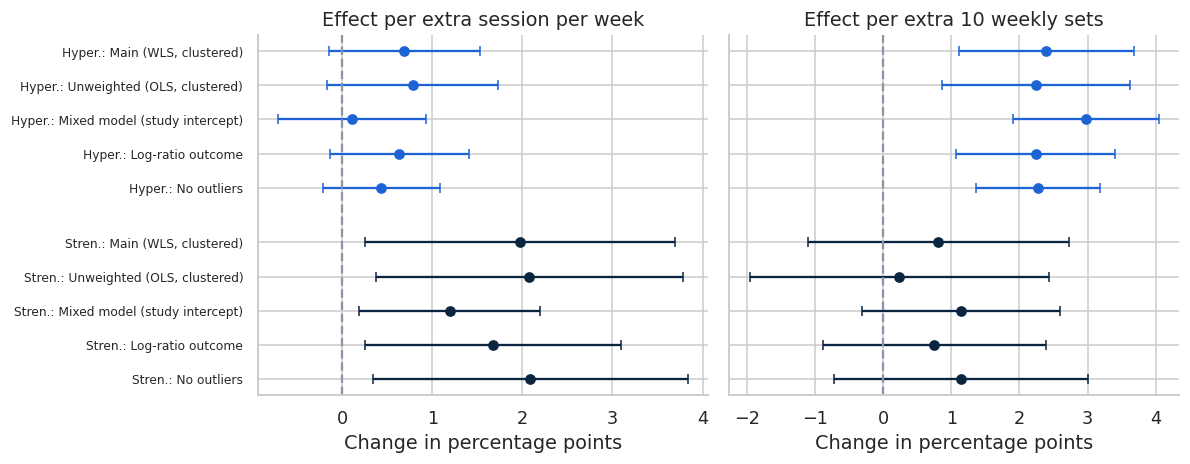

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for a, (t, lab) in zip(ax, [("f_c", "per extra session per week"), ("s_c", "per extra 10 weekly sets")]):
    y = 0; ticks = []
    for o in D:
        for v, vals in rob[o].items():
            c = vals[t]; a.errorbar(c["b"], y, xerr=[[c["b"] - c["low"]], [c["high"] - c["b"]]], fmt="o", color=COL[o], capsize=3)
            ticks.append((y, f"{o[:5]}.: {v}")); y -= 1
        y -= .6
    a.axvline(0, color=GREY, ls="--"); a.set_title(f"Effect {lab}"); a.set_xlabel("Change in percentage points")
ax[0].set_yticks([t[0] for t in ticks]); ax[0].set_yticklabels([t[1] for t in ticks], fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "fig6_robustness.png", dpi=200); plt.show()

**Does the story depend on the setup? No.**
- Hypertrophy and weekly sets: positive and significant in all five versions (2.24 to 2.98 points per 10 sets, every p ≤ .002).
- Hypertrophy and frequency: never significant after volume (0.11 to 0.78, every p ≥ .10).
- Strength and frequency: positive in all five (1.19 to 2.09 points per session, p between .017 and .025).
- Strength and weekly sets: never significant (0.23 to 1.14, p between .124 and .832).

## 10. Model-based pictures

These curves come from the chosen models, with everything else held at its average. The bands are 95% confidence intervals using study-clustered standard errors.

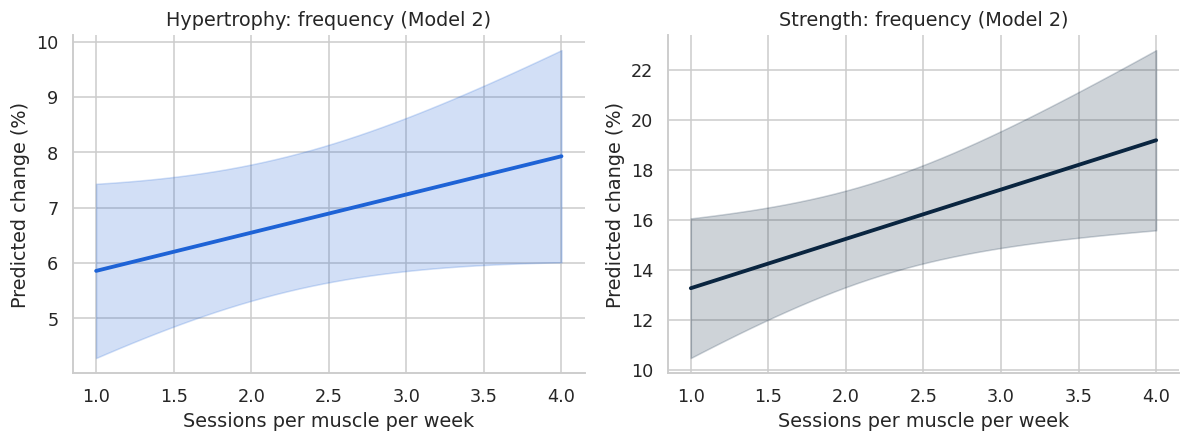

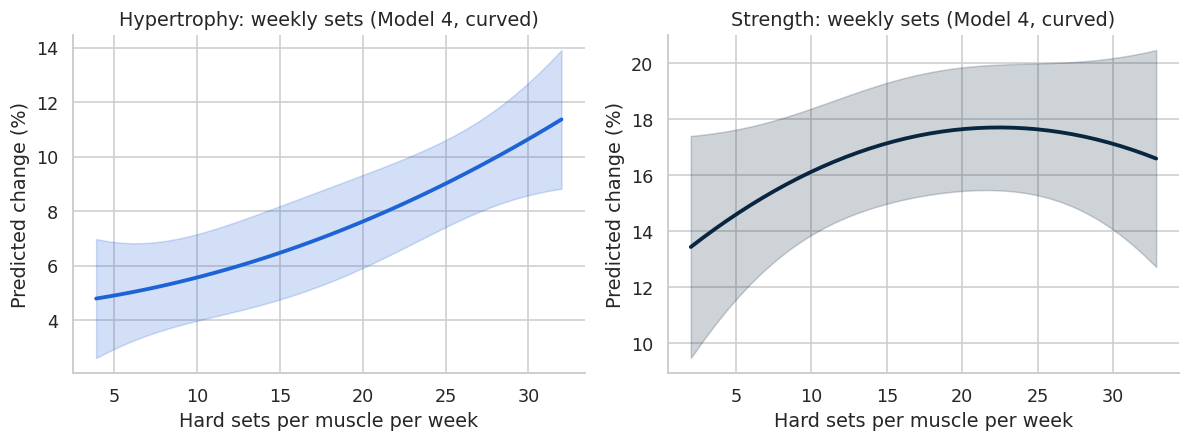

In [25]:
def grid_pred(o, model, var, values, other_at=0.0):
    x = D[o]; base = {"f_c": 0.0, "s_c": 0.0, "w_c": 0.0, "age_c": 0.0, "male_c": 0.0, "trained": x["trained"].mean()}
    rows = []
    for v in values:
        r = dict(base); r.update(var(v)); rows.append(r)
    nd = pd.DataFrame(rows)
    return M[o][model].get_prediction(nd).summary_frame()

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for a, o in zip(ax, D):
    x = D[o]; fgrid = np.linspace(max(1, x["freq"].min()), min(4, x["freq"].max()), 40)
    pr = grid_pred(o, "M2", lambda v: {"f_c": v - x["freq"].mean()}, fgrid)
    a.plot(fgrid, pr["mean"], color=COL[o], lw=2.5); a.fill_between(fgrid, pr["mean_ci_lower"], pr["mean_ci_upper"], color=COL[o], alpha=.2)
    a.set_title(f"{o}: frequency (Model 2)"); a.set_xlabel("Sessions per muscle per week"); a.set_ylabel("Predicted change (%)")
plt.tight_layout(); plt.savefig(FIG / "fig7_frequency_effect.png", dpi=200); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for a, o in zip(ax, D):
    x = D[o]; sgrid = np.linspace(x["sets"].quantile(.05), x["sets"].quantile(.95), 40)
    pr = grid_pred(o, "M4", lambda v: {"s_c": (v - x["sets"].mean()) / 10}, sgrid)
    a.plot(sgrid, pr["mean"], color=COL[o], lw=2.5); a.fill_between(sgrid, pr["mean_ci_lower"], pr["mean_ci_upper"], color=COL[o], alpha=.2)
    a.set_title(f"{o}: weekly sets (Model 4, curved)"); a.set_xlabel("Hard sets per muscle per week"); a.set_ylabel("Predicted change (%)")
plt.tight_layout(); plt.savefig(FIG / "fig8_volume_effect.png", dpi=200); plt.show()

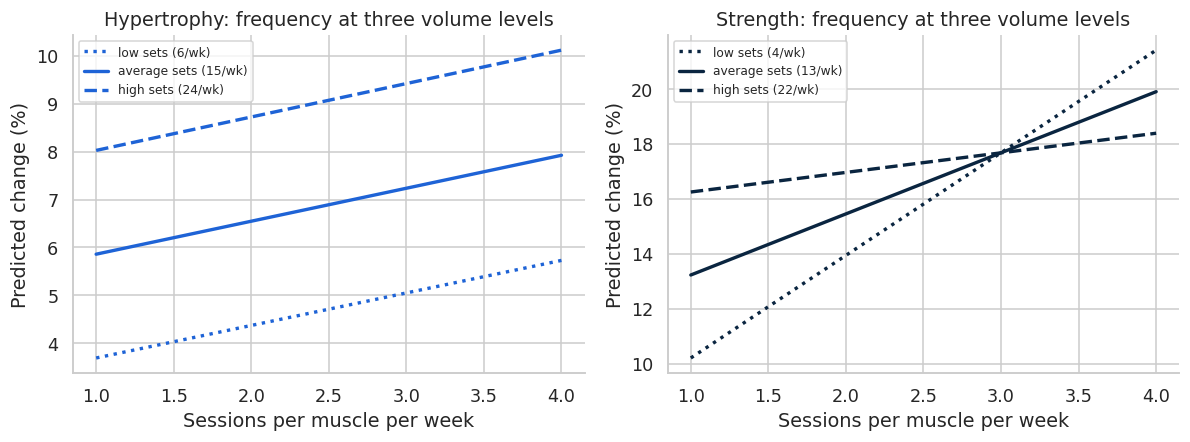

{'Hypertrophy': {'low (−1 SD)': 0.68, 'average': 0.69, 'high (+1 SD)': 0.7}, 'Strength': {'low (−1 SD)': 3.74, 'average': 2.22, 'high (+1 SD)': 0.71}}


In [26]:
# does the frequency effect change with volume? slope of frequency at low / average / high weekly sets (Model 3)
inter = {}
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for a, o in zip(ax, D):
    x = D[o]; m = M[o]["M3"]; V = m.cov_params(); sd = x["s_c"].std()
    slopes = {}
    for lab, s in [("low (−1 SD)", -sd), ("average", 0.0), ("high (+1 SD)", sd)]:
        b = m.params["f_c"] + m.params["f_c:s_c"] * s
        se = np.sqrt(V.loc["f_c", "f_c"] + s ** 2 * V.loc["f_c:s_c", "f_c:s_c"] + 2 * s * V.loc["f_c", "f_c:s_c"])
        slopes[lab] = {"b": float(b), "se": float(se), "sets": float(x["sets"].mean() + s * 10)}
    inter[o] = slopes
    fgrid = np.linspace(1, 4, 30)
    for (lab, s), ls in zip([("low sets", -sd), ("average sets", 0.0), ("high sets", sd)], [":", "-", "--"]):
        pr = grid_pred(o, "M3", lambda v: {"f_c": v - x["freq"].mean(), "s_c": s}, fgrid)
        a.plot(fgrid, pr["mean"], color=COL[o], ls=ls, lw=2.2, label=f"{lab} ({x['sets'].mean() + s * 10:.0f}/wk)")
    a.set_title(f"{o}: frequency at three volume levels"); a.set_xlabel("Sessions per muscle per week"); a.set_ylabel("Predicted change (%)"); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "fig9_interaction.png", dpi=200); plt.show()
RES["interaction"] = inter
print({o: {k: round(v["b"], 2) for k, v in d_.items()} for o, d_ in inter.items()})

In the strength panel the lines fan out at low volume and squeeze together at high volume: more sessions per week help when the weekly set count is small, and add little once volume is already high. In the hypertrophy panel the lines are parallel.

## 11. Saving what we reuse

In [27]:
RES["forms"] = FORM
RES["means"] = {o: {"freq": float(D[o]["freq"].mean()), "sets": float(D[o]["sets"].mean()), "weeks": float(D[o]["weeks"].mean()),
                    "age": float(D[o]["age"].mean()), "male": float(D[o]["male"].mean()), "trained": float(D[o]["trained"].mean())} for o in D}
with open(TAB / "results.json", "w") as f:
    json.dump(RES, f, indent=1, default=float)
print("saved", (TAB / "results.json").resolve())

saved /mnt/attach/outputs/data200_real/results/tables/results.json
